### **Import Libraries**

In [214]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Student Performance Dataset**

#### **Dataset Features**

##### Column	Description
##### StudentID Unique identifier for each student.
##### Name	Randomly generated student name.
##### Gender	Gender of the student (Male / Female).
##### AttendanceRate	Percentage of classes attended. (Some values exceed 100% for error-handling practice)
##### StudyHoursPerWeek	Hours spent studying weekly. (Some values are negative for error-handling practice)
##### PreviousGrade	Grade from the previous semester (out of 100).
##### ExtracurricularActivities	Number of extracurricular activities.
##### ParentalSupport	Level of parental support (High / Medium / Low).
##### FinalGrade	Final grade (out of 100) — Target variable for prediction.
##### Study Hours	Daily study hours (new column).
##### Attendance (%)	Attendance percentage in numeric form (new column).
##### Online Classes Taken	Whether the student has attended online classes (True / False).

#### **Gathering Data**

In [215]:
df = pd.read_csv('/content/drive/MyDrive/Machine Learning/data_set/student_performance_updated_1000.csv')
df


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
995,NaN,Kenneth Murray,Male,85.0,20.0,NaN,1.0,High,72.0,0.8,80.0,True
996,4497.0,Amy Stout,Female,91.0,NaN,86.0,0.0,High,90.0,3.9,80.0,True
997,1886.0,NaN,Male,85.0,8.0,82.0,2.0,Low,68.0,0.4,54.0,False
998,7636.0,Joseph Sherman,Male,88.0,17.0,60.0,2.0,High,85.0,0.9,53.0,True


### **EDA**

In [216]:
df.shape

(1000, 12)

In [217]:
df.dtypes

,0
StudentID,float64
Name,object
Gender,object
AttendanceRate,float64
StudyHoursPerWeek,float64
PreviousGrade,float64
ExtracurricularActivities,float64
ParentalSupport,object
FinalGrade,float64
Study Hours,float64


In [218]:
df.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,950.000000,967.000000,957.000000,960.000000,976.000000,959.000000
mean,5416.019792,85.510417,17.630526,77.598759,1.520376,80.030208,2.406967,77.248175
std,2653.748319,7.332125,6.272132,10.006640,1.046439,9.493652,1.620267,19.298148
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3113.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,63.000000
50%,5396.500000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,7754.750000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


In [219]:
df.isna().sum()

,0
StudentID,40
Name,34
Gender,48
AttendanceRate,40
StudyHoursPerWeek,50
PreviousGrade,33
ExtracurricularActivities,43
ParentalSupport,22
FinalGrade,40
Study Hours,24


In [220]:
print(df['StudentID'].duplicated().unique())

df[df['StudentID'].duplicated()].query(f'StudentID > 1')

[False  True]


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
247,4394.0,Brian Castro,Male,NaN,NaN,82.0,0.0,Low,92.0,2.8,74.0,False
290,1152.0,NaN,Male,NaN,20.0,60.0,0.0,Medium,87.0,1.1,55.0,True
324,7363.0,Ariana Morse,Female,78.0,15.0,88.0,3.0,High,80.0,4.5,99.0,False
353,8237.0,Melissa Morris,Male,70.0,17.0,70.0,1.0,High,72.0,4.0,54.0,False
396,8381.0,Stephanie Mcfarland,Female,91.0,12.0,65.0,1.0,High,72.0,3.7,85.0,False
479,9576.0,Elizabeth Wright,Female,95.0,17.0,70.0,3.0,High,78.0,1.5,76.0,False
505,9747.0,Angela Perez,Female,95.0,30.0,70.0,1.0,Medium,62.0,3.8,77.0,False
517,7939.0,Michael Kelly,Female,95.0,25.0,88.0,1.0,Low,80.0,3.8,60.0,False
532,4804.0,Nathan Wall,Male,85.0,30.0,85.0,1.0,High,72.0,4.2,80.0,False
538,1893.0,Lori Carrillo,Male,85.0,17.0,85.0,2.0,High,68.0,3.9,94.0,True


In [221]:
df.query('StudentID == 4394.0')

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
120,4394.0,John Warner,Male,92.0,30.0,65.0,3.0,High,NaN,4.3,59.0,True
247,4394.0,Brian Castro,Male,NaN,NaN,82.0,0.0,Low,92.0,2.8,74.0,False


In [222]:
print(df.query('Name == "Brian Castro"'))

df[df['Name'].duplicated()].count() # 4 Names duplicate

     StudentID          Name Gender  AttendanceRate  StudyHoursPerWeek  \
247     4394.0  Brian Castro   Male             NaN                NaN   

     PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  \
247           82.0                        0.0             Low        92.0   

     Study Hours  Attendance (%) Online Classes Taken  
247          2.8            74.0                False  


,0
StudentID,37
Name,4
Gender,35
AttendanceRate,35
StudyHoursPerWeek,34
PreviousGrade,36
ExtracurricularActivities,35
ParentalSupport,36
FinalGrade,36
Study Hours,36


In [223]:
print(df['Gender'].unique())
print(df['ParentalSupport'].unique())
df['Online Classes Taken'].unique()

['Male' 'Female' nan]
['High' 'Medium' 'Low' nan]


array([False, True, nan], dtype=object)

In [224]:
df['ParentalSupport'].value_counts()

,count
ParentalSupport,
High,345
Medium,328
Low,305


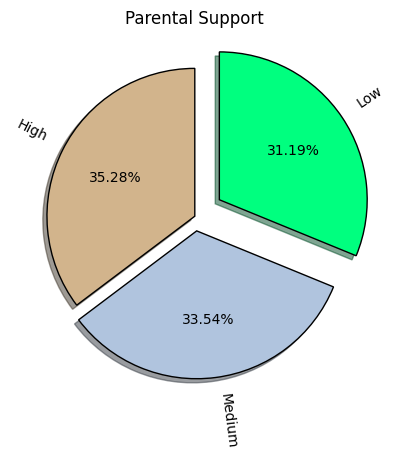

In [225]:
values = df['ParentalSupport'].dropna().value_counts() / len(df) * 100
labels = list(values.index)
colors = ['tan', 'lightsteelblue', 'springgreen']
explode = (0, .1, .2)

plt.pie(x = values, labels = labels, colors = colors, startangle = 90, rotatelabels = True,
        shadow = True, explode = explode, autopct = '%1.2f%%', wedgeprops = {'edgecolor':'k'})
plt.title('Parental Support')
plt.show()

In [226]:
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


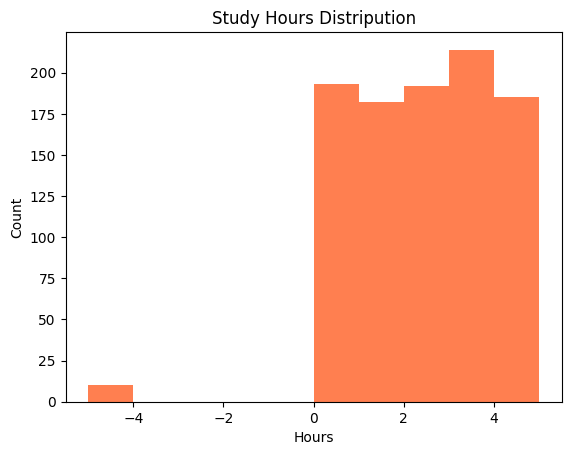

In [227]:
plt.hist(df['Study Hours'], bins = 10, color = 'coral')
plt.xlabel('Hours')
plt.ylabel('Count')
plt.title('Study Hours Distripution')
plt.show()

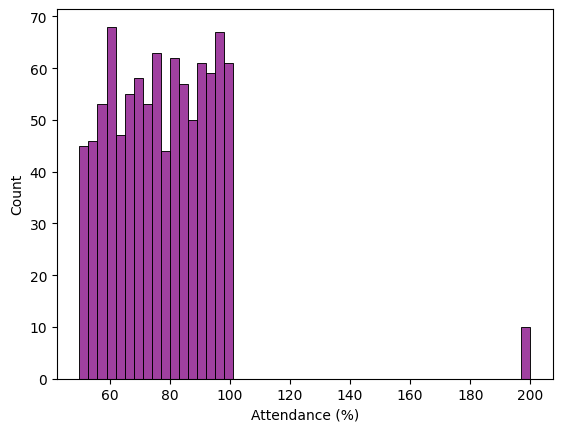

In [228]:
sns.histplot(data = df, x = 'Attendance (%)', bins = 50, color = 'purple')
plt.show()

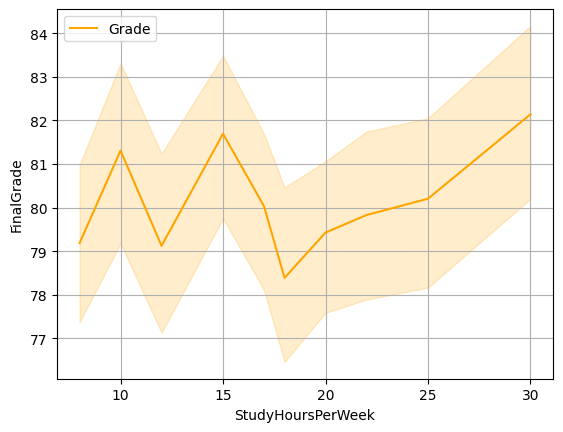

In [229]:
sns.lineplot(data = df, x = 'StudyHoursPerWeek', y = 'FinalGrade', label = 'Grade', color = 'orange')
plt.legend()
plt.grid(True)
plt.show()

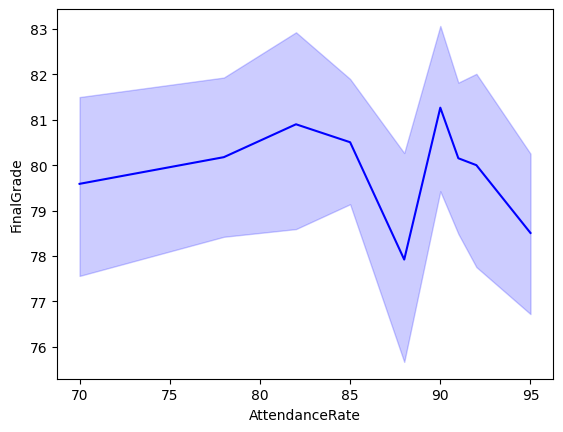

In [230]:
sns.lineplot(data = df, x = 'AttendanceRate' , y = 'FinalGrade', color = 'blue')
plt.show()

In [231]:
(df['Study Hours'] < 0).unique()
df[df['Study Hours'] < 0]

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
74,1470.0,Michelle Jones,Female,95.0,10.0,77.0,3.0,Medium,85.0,-5.0,200.0,False
125,3430.0,Jessica Lamb,Male,78.0,18.0,86.0,NaN,Low,90.0,-5.0,200.0,False
148,5059.0,Michaela Powell,Female,85.0,12.0,70.0,3.0,High,90.0,-5.0,200.0,False
220,8484.0,Alicia Ortiz,Male,82.0,17.0,82.0,1.0,Medium,85.0,-5.0,200.0,True
251,3527.0,Michael Foster,Female,95.0,30.0,NaN,2.0,High,85.0,-5.0,200.0,False
321,3831.0,Jessica Jenkins,Female,92.0,10.0,82.0,2.0,NaN,68.0,-5.0,200.0,True
366,4659.0,Jill Kelly,Female,70.0,30.0,NaN,2.0,Low,85.0,-5.0,200.0,False
380,6416.0,Raymond Murillo,Male,85.0,15.0,85.0,2.0,Low,78.0,-5.0,200.0,True
672,8203.0,David Martinez,Male,78.0,30.0,60.0,0.0,High,72.0,-5.0,200.0,False
798,1378.0,Chad Colon,Female,82.0,17.0,78.0,NaN,Low,80.0,-5.0,200.0,False


In [232]:
df[df['Attendance (%)'] > 100]

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
74,1470.0,Michelle Jones,Female,95.0,10.0,77.0,3.0,Medium,85.0,-5.0,200.0,False
125,3430.0,Jessica Lamb,Male,78.0,18.0,86.0,NaN,Low,90.0,-5.0,200.0,False
148,5059.0,Michaela Powell,Female,85.0,12.0,70.0,3.0,High,90.0,-5.0,200.0,False
220,8484.0,Alicia Ortiz,Male,82.0,17.0,82.0,1.0,Medium,85.0,-5.0,200.0,True
251,3527.0,Michael Foster,Female,95.0,30.0,NaN,2.0,High,85.0,-5.0,200.0,False
321,3831.0,Jessica Jenkins,Female,92.0,10.0,82.0,2.0,NaN,68.0,-5.0,200.0,True
366,4659.0,Jill Kelly,Female,70.0,30.0,NaN,2.0,Low,85.0,-5.0,200.0,False
380,6416.0,Raymond Murillo,Male,85.0,15.0,85.0,2.0,Low,78.0,-5.0,200.0,True
672,8203.0,David Martinez,Male,78.0,30.0,60.0,0.0,High,72.0,-5.0,200.0,False
798,1378.0,Chad Colon,Female,82.0,17.0,78.0,NaN,Low,80.0,-5.0,200.0,False


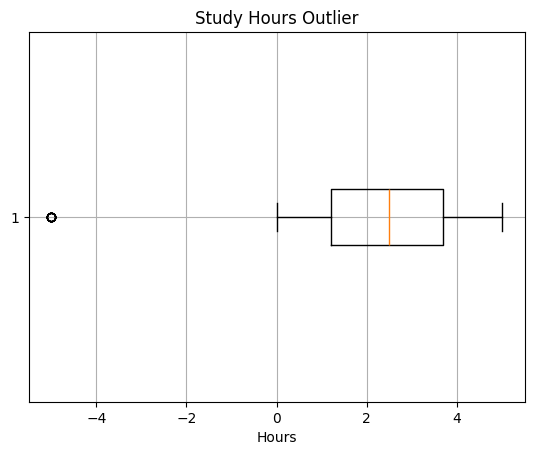

In [233]:
plt.boxplot(x = df['Study Hours'].dropna(), vert = False, showbox = True)
plt.title('Study Hours Outlier')
plt.xlabel('Hours')
plt.grid()
plt.show()

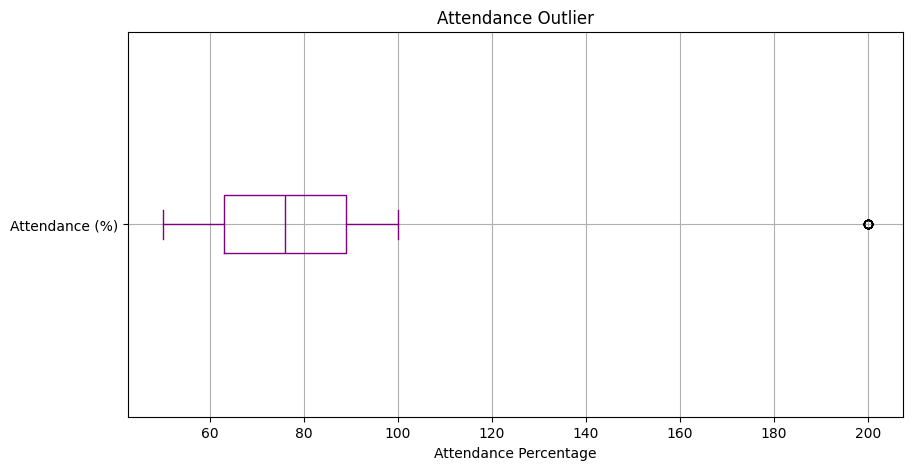

In [234]:
df.boxplot(column = 'Attendance (%)', vert = False, color = 'purple', figsize = (10, 5))
plt.title('Attendance Outlier')
plt.xlabel('Attendance Percentage')
plt.show()

In [235]:
df.head(10)

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
5,6.0,Olivia,Female,95.0,30.0,88.0,1.0,High,NaN,2.8,97.0,False
6,7.0,Daniel,Male,70.0,8.0,60.0,0.0,Low,62.0,4.5,96.0,False
7,8.0,Sophia,Female,NaN,17.0,77.0,1.0,Medium,78.0,1.0,70.0,True
8,9.0,James,Male,82.0,12.0,70.0,2.0,Low,72.0,3.6,50.0,False
9,10.0,Isabella,Female,91.0,22.0,86.0,3.0,High,88.0,2.9,59.0,True


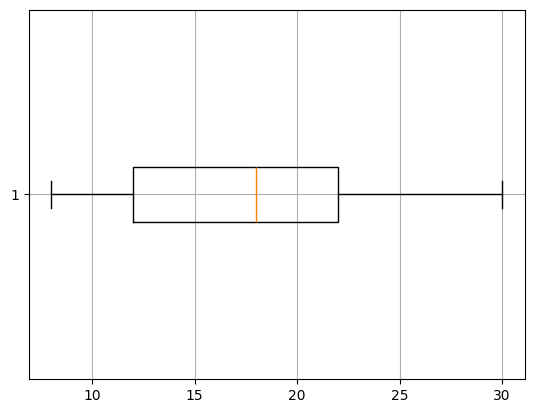

In [236]:
plt.boxplot(x = df['StudyHoursPerWeek'].dropna(), vert = False, showbox = True)
plt.grid()
plt.show()

In [237]:
df['Online Classes Taken'].mode()

,Online Classes Taken
0,True


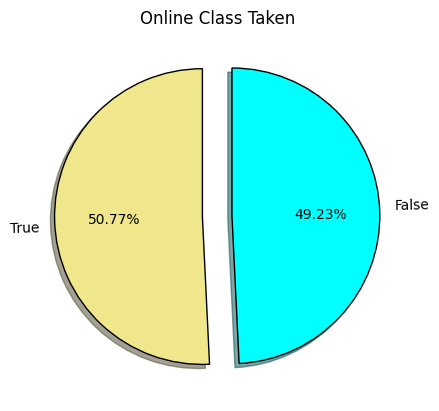

In [238]:
values = df['Online Classes Taken'].dropna().value_counts()/len(df) * 100
labels = list(values.index)
colors = ['khaki', 'aqua']

plt.pie(x = values, labels = labels, colors = colors, autopct = '%1.2f%%', shadow = True,
        explode = (.1, .1), startangle = 90, rotatelabels = True, wedgeprops = {'edgecolor':'k'})
plt.title('Online Class Taken')
plt.show()

### **Data Preprocessing**

In [239]:
df.isna().sum()

,0
StudentID,40
Name,34
Gender,48
AttendanceRate,40
StudyHoursPerWeek,50
PreviousGrade,33
ExtracurricularActivities,43
ParentalSupport,22
FinalGrade,40
Study Hours,24


In [240]:
df['StudentID'].isna().sum()

np.int64(40)

In [241]:
df = df.dropna(subset = 'StudentID')
df['StudentID'].isna().sum()

np.int64(0)

In [242]:
df[df['StudentID'].duplicated()]

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
247,4394.0,Brian Castro,Male,NaN,NaN,82.0,0.0,Low,92.0,2.8,74.0,False
290,1152.0,NaN,Male,NaN,20.0,60.0,0.0,Medium,87.0,1.1,55.0,True
324,7363.0,Ariana Morse,Female,78.0,15.0,88.0,3.0,High,80.0,4.5,99.0,False
353,8237.0,Melissa Morris,Male,70.0,17.0,70.0,1.0,High,72.0,4.0,54.0,False
396,8381.0,Stephanie Mcfarland,Female,91.0,12.0,65.0,1.0,High,72.0,3.7,85.0,False
479,9576.0,Elizabeth Wright,Female,95.0,17.0,70.0,3.0,High,78.0,1.5,76.0,False
505,9747.0,Angela Perez,Female,95.0,30.0,70.0,1.0,Medium,62.0,3.8,77.0,False
517,7939.0,Michael Kelly,Female,95.0,25.0,88.0,1.0,Low,80.0,3.8,60.0,False
532,4804.0,Nathan Wall,Male,85.0,30.0,85.0,1.0,High,72.0,4.2,80.0,False
538,1893.0,Lori Carrillo,Male,85.0,17.0,85.0,2.0,High,68.0,3.9,94.0,True


In [243]:
df = df.drop_duplicates(subset = ['StudentID'], keep = 'first')
print(df.shape)
df['StudentID'].duplicated().sum()

(916, 12)


np.int64(0)

In [244]:
df[df['Name'].isna()]

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
116,2592.0,NaN,Male,82.0,10.0,60.0,1.0,Medium,72.0,2.1,97.0,True
166,7338.0,NaN,Female,88.0,15.0,88.0,2.0,Medium,92.0,3.7,90.0,True
180,6922.0,NaN,Male,90.0,25.0,65.0,3.0,Medium,80.0,1.8,86.0,False
181,8657.0,NaN,Male,91.0,20.0,85.0,2.0,Medium,78.0,2.6,99.0,False
291,2690.0,NaN,Female,95.0,18.0,65.0,0.0,High,68.0,0.3,86.0,True
343,5315.0,NaN,Male,NaN,22.0,78.0,0.0,Low,87.0,0.4,72.0,False
360,4575.0,NaN,Female,88.0,12.0,86.0,0.0,Low,87.0,0.0,92.0,NaN
382,5760.0,NaN,Female,95.0,8.0,85.0,2.0,High,80.0,4.3,NaN,True
390,7607.0,NaN,NaN,90.0,17.0,77.0,3.0,Medium,87.0,4.3,78.0,False
420,4441.0,NaN,Female,92.0,8.0,70.0,0.0,High,68.0,1.1,66.0,True


In [245]:
df.loc[:,'Name'] = df['Name'].fillna('Unknown')
print(df['Name'].isna().sum())
df.query('Name == "Unknown"')

0


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
116,2592.0,Unknown,Male,82.0,10.0,60.0,1.0,Medium,72.0,2.1,97.0,True
166,7338.0,Unknown,Female,88.0,15.0,88.0,2.0,Medium,92.0,3.7,90.0,True
180,6922.0,Unknown,Male,90.0,25.0,65.0,3.0,Medium,80.0,1.8,86.0,False
181,8657.0,Unknown,Male,91.0,20.0,85.0,2.0,Medium,78.0,2.6,99.0,False
291,2690.0,Unknown,Female,95.0,18.0,65.0,0.0,High,68.0,0.3,86.0,True
343,5315.0,Unknown,Male,NaN,22.0,78.0,0.0,Low,87.0,0.4,72.0,False
360,4575.0,Unknown,Female,88.0,12.0,86.0,0.0,Low,87.0,0.0,92.0,NaN
382,5760.0,Unknown,Female,95.0,8.0,85.0,2.0,High,80.0,4.3,NaN,True
390,7607.0,Unknown,NaN,90.0,17.0,77.0,3.0,Medium,87.0,4.3,78.0,False
420,4441.0,Unknown,Female,92.0,8.0,70.0,0.0,High,68.0,1.1,66.0,True


In [246]:
df.isna().sum()

,0
StudentID,0
Name,0
Gender,42
AttendanceRate,34
StudyHoursPerWeek,48
PreviousGrade,31
ExtracurricularActivities,42
ParentalSupport,22
FinalGrade,36
Study Hours,20


In [247]:
df[df['Gender'].isna()]

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
33,1960.0,Kristina Douglas,NaN,NaN,15.0,60.0,2.0,Medium,85.0,2.1,96.0,False
89,5102.0,Alyssa Schmidt,NaN,90.0,25.0,86.0,3.0,High,85.0,2.9,98.0,True
91,7690.0,Alyssa Smith,NaN,95.0,20.0,65.0,1.0,Medium,78.0,1.4,75.0,True
101,9617.0,Emily Torres,NaN,85.0,NaN,60.0,0.0,High,78.0,3.9,66.0,False
102,7512.0,Nancy Davis,NaN,95.0,12.0,60.0,1.0,Low,78.0,4.4,52.0,True
106,4804.0,James Anderson,NaN,88.0,17.0,82.0,1.0,Medium,85.0,3.4,60.0,True
117,7797.0,Angela Williams,NaN,85.0,22.0,60.0,2.0,High,NaN,1.1,78.0,NaN
200,3421.0,Jeffrey Meyers,NaN,85.0,22.0,85.0,3.0,High,78.0,1.6,59.0,False
216,2923.0,Paul Hickman,NaN,95.0,22.0,90.0,3.0,High,78.0,0.8,97.0,False
228,7775.0,Jose Liu,NaN,88.0,15.0,70.0,3.0,Low,68.0,3.1,77.0,False


In [248]:
df = df.dropna(subset = ['Gender'])
df['Gender'].isna().sum()

np.int64(0)

In [249]:
df[df['AttendanceRate'].isna()]

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
7,8.0,Sophia,Female,NaN,17.0,77.0,1.0,Medium,78.0,1.0,70.0,True
15,2139.0,Derrick Alexander,Male,NaN,18.0,85.0,3.0,High,62.0,1.4,90.0,False
26,3705.0,Jeremy Hall,Female,NaN,NaN,60.0,3.0,Low,92.0,3.6,75.0,False
157,4271.0,Frank Dawson,Male,NaN,15.0,77.0,1.0,Low,87.0,3.6,83.0,True
174,2229.0,Nathaniel Kemp,Female,NaN,12.0,65.0,1.0,High,88.0,3.4,78.0,True
229,1768.0,Cathy Pratt,Female,NaN,12.0,88.0,0.0,Medium,68.0,1.5,61.0,False
270,6993.0,Vincent Smith,Female,NaN,17.0,85.0,2.0,Low,78.0,2.6,90.0,False
274,3733.0,Barry Parker,Female,NaN,10.0,65.0,1.0,Medium,88.0,NaN,72.0,True
325,1959.0,Brian Avery,Female,NaN,NaN,86.0,3.0,High,87.0,1.2,65.0,False


In [250]:
df['AttendanceRate'] = df['AttendanceRate'].fillna(df['AttendanceRate'].mean())
df['StudyHoursPerWeek'] = df['StudyHoursPerWeek'].fillna(df['StudyHoursPerWeek'].mean())
df['PreviousGrade'] = df['PreviousGrade'].fillna(df['PreviousGrade'].mean())
df['ExtracurricularActivities'] = df['ExtracurricularActivities'].fillna(df['ExtracurricularActivities'].mode()[0])
df['ParentalSupport'] = df['ParentalSupport'].fillna(df['ParentalSupport'].mode()[0])
df['Online Classes Taken'] = df['Online Classes Taken'].fillna(df['Online Classes Taken'].mode()[0])

df.isna().sum()



/tmp/ipykernel_1507/3234102674.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Online Classes Taken'] = df['Online Classes Taken'].fillna(df['Online Classes Taken'].mode()[0])


,0
StudentID,0
Name,0
Gender,0
AttendanceRate,0
StudyHoursPerWeek,0
PreviousGrade,0
ExtracurricularActivities,0
ParentalSupport,0
FinalGrade,35
Study Hours,19


In [251]:
df[df['Attendance (%)'] > 100]

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
74,1470.0,Michelle Jones,Female,95.0,10.0,77.000000,3.0,Medium,85.0,-5.0,200.0,False
125,3430.0,Jessica Lamb,Male,78.0,18.0,86.000000,1.0,Low,90.0,-5.0,200.0,False
148,5059.0,Michaela Powell,Female,85.0,12.0,70.000000,3.0,High,90.0,-5.0,200.0,False
220,8484.0,Alicia Ortiz,Male,82.0,17.0,82.000000,1.0,Medium,85.0,-5.0,200.0,True
251,3527.0,Michael Foster,Female,95.0,30.0,77.855279,2.0,High,85.0,-5.0,200.0,False
321,3831.0,Jessica Jenkins,Female,92.0,10.0,82.000000,2.0,High,68.0,-5.0,200.0,True
366,4659.0,Jill Kelly,Female,70.0,30.0,77.855279,2.0,Low,85.0,-5.0,200.0,False
380,6416.0,Raymond Murillo,Male,85.0,15.0,85.000000,2.0,Low,78.0,-5.0,200.0,True
672,8203.0,David Martinez,Male,78.0,30.0,60.000000,0.0,High,72.0,-5.0,200.0,False
798,1378.0,Chad Colon,Female,82.0,17.0,78.000000,1.0,Low,80.0,-5.0,200.0,False


In [252]:
df[df['Study Hours'] < 0]

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
74,1470.0,Michelle Jones,Female,95.0,10.0,77.000000,3.0,Medium,85.0,-5.0,200.0,False
125,3430.0,Jessica Lamb,Male,78.0,18.0,86.000000,1.0,Low,90.0,-5.0,200.0,False
148,5059.0,Michaela Powell,Female,85.0,12.0,70.000000,3.0,High,90.0,-5.0,200.0,False
220,8484.0,Alicia Ortiz,Male,82.0,17.0,82.000000,1.0,Medium,85.0,-5.0,200.0,True
251,3527.0,Michael Foster,Female,95.0,30.0,77.855279,2.0,High,85.0,-5.0,200.0,False
321,3831.0,Jessica Jenkins,Female,92.0,10.0,82.000000,2.0,High,68.0,-5.0,200.0,True
366,4659.0,Jill Kelly,Female,70.0,30.0,77.855279,2.0,Low,85.0,-5.0,200.0,False
380,6416.0,Raymond Murillo,Male,85.0,15.0,85.000000,2.0,Low,78.0,-5.0,200.0,True
672,8203.0,David Martinez,Male,78.0,30.0,60.000000,0.0,High,72.0,-5.0,200.0,False
798,1378.0,Chad Colon,Female,82.0,17.0,78.000000,1.0,Low,80.0,-5.0,200.0,False


In [253]:
df.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,874.000000,874.000000,874.000000,874.000000,874.000000,839.000000,855.000000,838.000000
mean,5404.653318,85.453032,17.522892,77.855279,1.502288,80.441001,2.380936,77.599045
std,2656.324517,7.140257,6.136950,9.811998,1.021249,9.426947,1.647686,19.869325
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3108.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.100000,64.000000
50%,5361.000000,85.453032,17.522892,78.000000,1.000000,85.000000,2.500000,76.000000
75%,7762.250000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,90.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


In [254]:
outlier_rows = df['Study Hours'] < 0
df.loc[outlier_rows, 'Study Hours'] = 0

outlier_rows = df['Attendance (%)'] > 100
df.loc[outlier_rows, 'Attendance (%)'] = 100

df.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,874.000000,874.000000,874.000000,874.000000,874.000000,839.000000,855.000000,838.000000
mean,5404.653318,85.453032,17.522892,77.855279,1.502288,80.441001,2.439415,76.405728
std,2656.324517,7.140257,6.136950,9.811998,1.021249,9.426947,1.462843,14.844638
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,0.000000,50.000000
25%,3108.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.100000,64.000000
50%,5361.000000,85.453032,17.522892,78.000000,1.000000,85.000000,2.500000,76.000000
75%,7762.250000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,90.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,100.000000


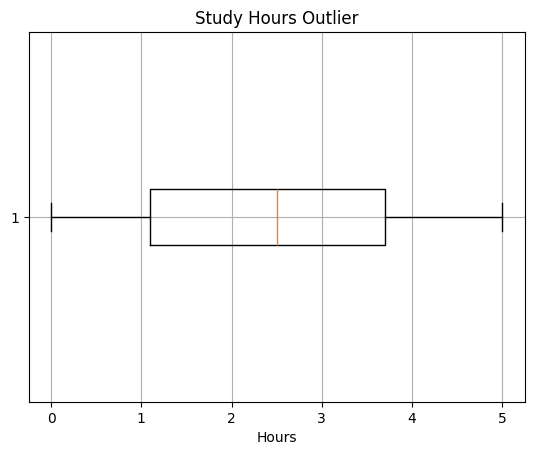

In [255]:
plt.boxplot(x = df['Study Hours'].dropna(), vert = False, showbox = True)
plt.title('Study Hours Outlier') # No outlier
plt.xlabel('Hours')
plt.grid()
plt.show()

In [256]:
df['Attendance (%)'] = df['Attendance (%)'].fillna(df['Attendance (%)'].mean())
df['Study Hours'] = df['Study Hours'].fillna(df['Study Hours'].mean())
df['FinalGrade'] = df['FinalGrade'].fillna(df['FinalGrade'].mean())

df.isna().sum()

,0
StudentID,0
Name,0
Gender,0
AttendanceRate,0
StudyHoursPerWeek,0
PreviousGrade,0
ExtracurricularActivities,0
ParentalSupport,0
FinalGrade,0
Study Hours,0


In [257]:
df['StudentID'] = range(1, len(df) + 1)
df['StudentID']

,StudentID
0,1
1,2
2,3
3,4
4,5
...,...
994,870
996,871
997,872
998,873


In [258]:
df.rename(columns = {'Attendance (%)':'Attendance', 'Study Hours':'StudyHours', 'Online Classes Taken':'OnlineClassesTaken'}, inplace = True)
df


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,StudyHours,Attendance,OnlineClassesTaken
0,1,John,Male,85.000000,15.000000,78.0,1.0,High,80.000000,4.8,59.0,False
1,2,Sarah,Female,90.000000,20.000000,85.0,2.0,Medium,87.000000,2.2,70.0,True
2,3,Alex,Male,78.000000,10.000000,65.0,0.0,Low,68.000000,4.6,92.0,False
3,4,Michael,Male,92.000000,25.000000,90.0,3.0,High,92.000000,2.9,96.0,False
4,5,Emma,Female,85.453032,18.000000,82.0,2.0,Medium,85.000000,4.1,97.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
994,870,Shannon Porter,Male,78.000000,20.000000,60.0,0.0,High,62.000000,1.6,70.0,False
996,871,Amy Stout,Female,91.000000,17.522892,86.0,0.0,High,90.000000,3.9,80.0,True
997,872,Unknown,Male,85.000000,8.000000,82.0,2.0,Low,68.000000,0.4,54.0,False
998,873,Joseph Sherman,Male,88.000000,17.000000,60.0,2.0,High,85.000000,0.9,53.0,True


In [259]:
df.columns

Index(['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek',
       'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport',
       'FinalGrade', 'StudyHours', 'Attendance', 'OnlineClassesTaken'],
      dtype='object')

In [260]:
df.to_csv('student_performance_data.csv', index = False)